In [3]:
%pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Dataset Summary ---
Total Rows: 4521, Total Columns: 17

--- Model Performance ---
Accuracy Score: 0.8873

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1201
           1       0.51      0.35      0.41       156

    accuracy                           0.89      1357
   macro avg       0.72      0.65      0.68      1357
weighted avg       0.87      0.89      0.88      1357



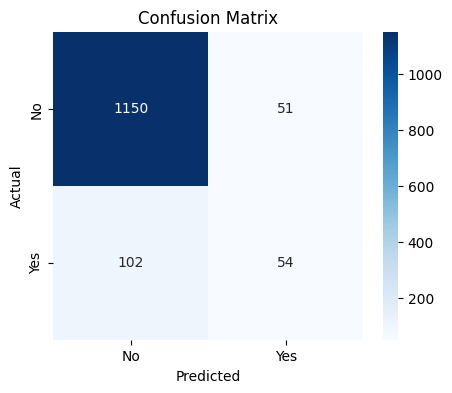

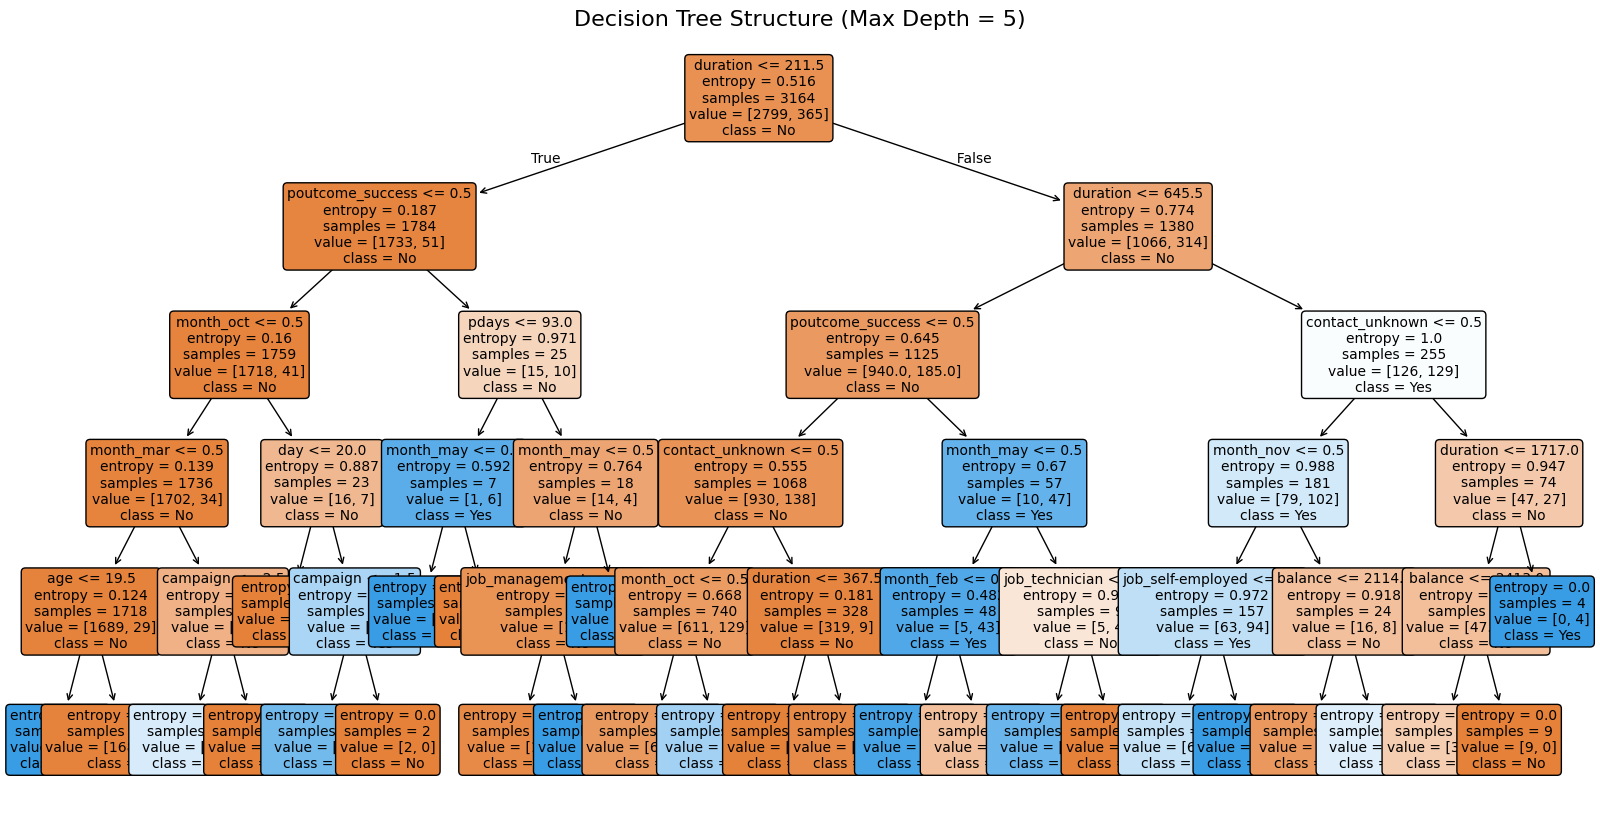

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
# Loading 'bank.csv' (using the semicolon separator)
df = pd.read_csv('bank.csv', sep=';')

print("--- Dataset Summary ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}\n")

# ==========================================
# 2. PREPROCESSING & ENCODING
# ==========================================
# Separate features (X) and target variable (y)
X = df.drop(columns=['y'])
y = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Convert all text categories to binary/numeric flags automatically
X_encoded = pd.get_dummies(X, drop_first=True)

# ==========================================
# 3. SPLIT DATA INTO TRAIN & TEST SETS
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# ==========================================
# 4. TRAIN THE DECISION TREE CLASSIFIER
# ==========================================
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# ==========================================
# 5. MODEL EVALUATION METRICS
# ==========================================
y_pred = clf.predict(X_test)

print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# ==========================================
# 6. VISUALIZE CONFUSION MATRIX & TREE
# ==========================================
# Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# Decision Tree Flowchart
plt.figure(figsize=(20, 10))
plot_tree(clf, 
          feature_names=list(X_encoded.columns), 
          class_names=['No', 'Yes'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Decision Tree Structure (Max Depth = 5)', fontsize=16)
plt.savefig('decision_tree_final.png', dpi=300, bbox_inches='tight')
plt.show()